# Machine Learning Project

By: Alejandro Arroyo, Vivi Lazo, Nyah Posey, Jessica Wentworth

## Section 0: Config

In [1]:
# Took ~20 min (RF+NN) + ~2.5 hrs (CNN) on i5-12600KF + RX 6700, 32GB RAM
DATA_PATH    = r"G:\My Drive\Machine Learning Group Project"   # <-- only line you need to change
RANDOM_STATE = 1996

## Section 1: Imports

In [2]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from joblib import Parallel, delayed
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")

PyTorch device: cpu


## Section 2: Shared Data Loader

In [3]:
def load_dataset(aug_version):
    """Load .npy files for a given aug version (e.g. '5aug' or '10aug')."""
    p = Path(DATA_PATH)
    X_train = np.load(p / f"X_train_{aug_version}.npy")
    X_val   = np.load(p / f"X_val_{aug_version}.npy")
    X_test  = np.load(p / f"X_test_{aug_version}.npy")
    y_train = np.load(p / f"y_train_{aug_version}.npy")
    y_val   = np.load(p / f"y_val_{aug_version}.npy")
    y_test  = np.load(p / f"y_test_{aug_version}.npy")
    return X_train, X_val, X_test, y_train, y_val, y_test

## Section 3: EDA


Dataset: 5aug
  Train shape: (21744, 12288) | Classes: 151 | Pixel range: 0.00–1.00
  Images per class: 144

Dataset: 10aug
  Train shape: (39864, 12288) | Classes: 151 | Pixel range: 0.00–1.00
  Images per class: 264


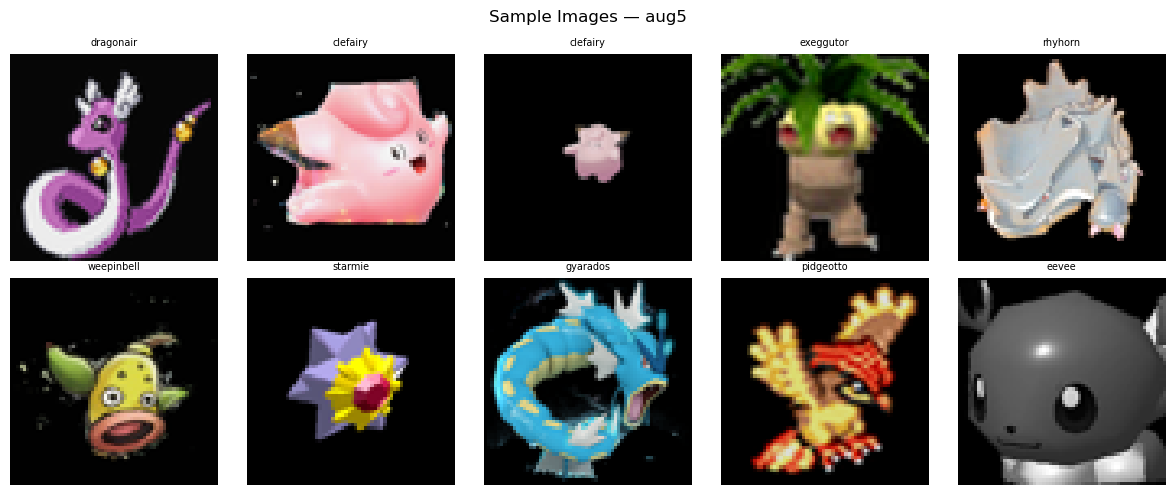

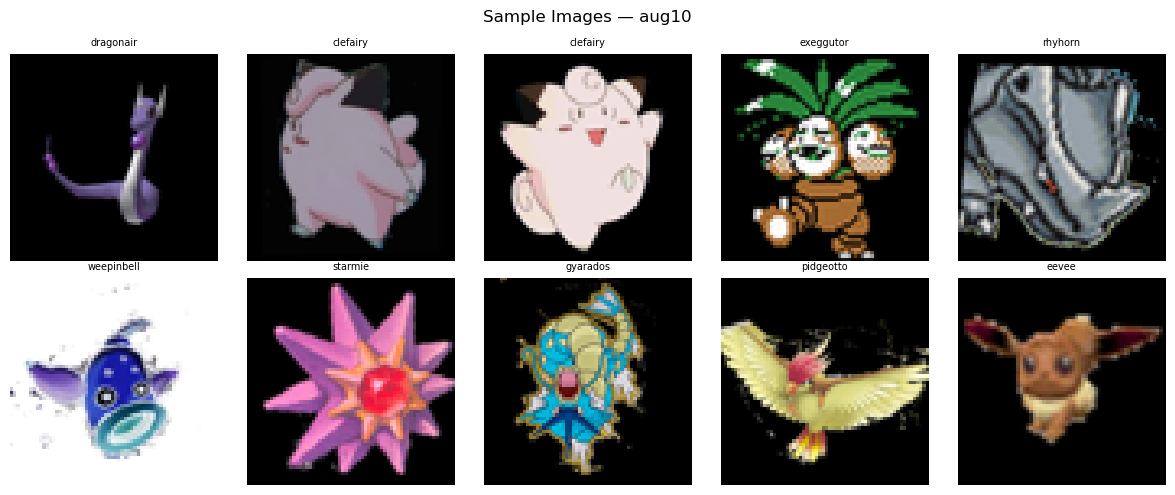

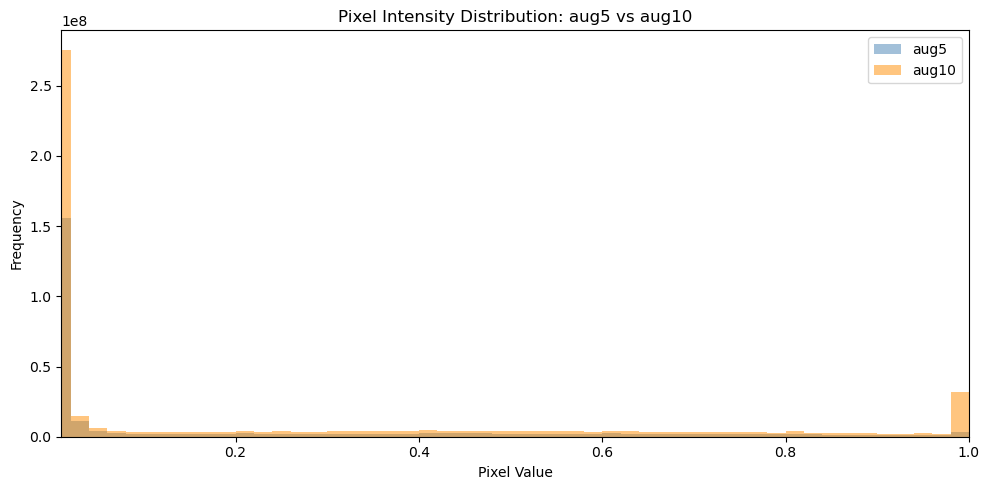

aug5 mean: 0.1863 | aug10 mean: 0.2294
Train/val overlap (aug5): 2 images
Train/val overlap (aug10): 2 images


In [4]:
X_train_5, X_val_5, X_test_5, y_train_5, y_val_5, y_test_5 = load_dataset("5aug")
X_train_10, X_val_10, X_test_10, y_train_10, y_val_10, y_test_10 = load_dataset("10aug")

for label, X, y in [("5aug", X_train_5, y_train_5), ("10aug", X_train_10, y_train_10)]:
    print(f"\nDataset: {label}")
    print(f"  Train shape: {X.shape} | Classes: {len(np.unique(y))} | Pixel range: {X.min():.2f}–{X.max():.2f}")
    print(f"  Images per class: {pd.Series(y).value_counts().iloc[0]}")

# Sample image preview
for label, X, y in [("aug5", X_train_5, y_train_5), ("aug10", X_train_10, y_train_10)]:
    rng = np.random.default_rng(RANDOM_STATE)
    indices = rng.choice(len(X), 10, replace=False)
    plt.figure(figsize=(12, 5))
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[idx].reshape(64, 64, 3))
        plt.title(y[idx], fontsize=7)
        plt.axis("off")
    plt.suptitle(f"Sample Images — {label}")
    plt.tight_layout()
    plt.show()

# Pixel intensity distribution
plt.figure(figsize=(10, 5))
plt.hist(X_train_5.flatten(),  bins=50, alpha=0.5, label="aug5",  color="steelblue")
plt.hist(X_train_10.flatten(), bins=50, alpha=0.5, label="aug10", color="darkorange")
plt.title("Pixel Intensity Distribution: aug5 vs aug10")
plt.xlabel("Pixel Value"); plt.ylabel("Frequency")
plt.xlim(0.01, 1.0)   # cuts off the massive transparent pixel spike at 0
plt.legend(); plt.tight_layout(); plt.show()
print(f"aug5 mean: {X_train_5.mean():.4f} | aug10 mean: {X_train_10.mean():.4f}")

# Data leakage check
def check_overlap(X_train, X_val, label):
    train_set = set(map(tuple, X_train.reshape(len(X_train), -1)))
    val_set   = set(map(tuple, X_val.reshape(len(X_val), -1)))
    print(f"Train/val overlap ({label}): {len(train_set & val_set)} images")

check_overlap(X_train_5, X_val_5, "aug5")
check_overlap(X_train_10, X_val_10, "aug10")

## Section 4: Random Forest


Random Forest — 5aug
  Extracting HOG features (parallelized)...
  Val Accuracy:  100.00%
  Test Accuracy: 29.14%
  ROC-AUC:       0.8041
              precision    recall  f1-score   support

        abra       0.25      0.38      0.30         8
  aerodactyl       0.31      0.50      0.38         8
    alakazam       0.36      0.62      0.45         8
       arbok       0.45      0.62      0.53         8
    arcanine       0.20      0.38      0.26         8
    articuno       0.12      0.12      0.12         8
    beedrill       0.25      0.12      0.17         8
  bellsprout       0.14      0.25      0.18         8
   blastoise       0.12      0.12      0.12         8
   bulbasaur       0.00      0.00      0.00         8
  butterfree       0.27      0.38      0.32         8
    caterpie       0.00      0.00      0.00         8
     chansey       0.32      0.75      0.44         8
   charizard       0.11      0.12      0.12         8
  charmander       0.60      0.38      0.46       

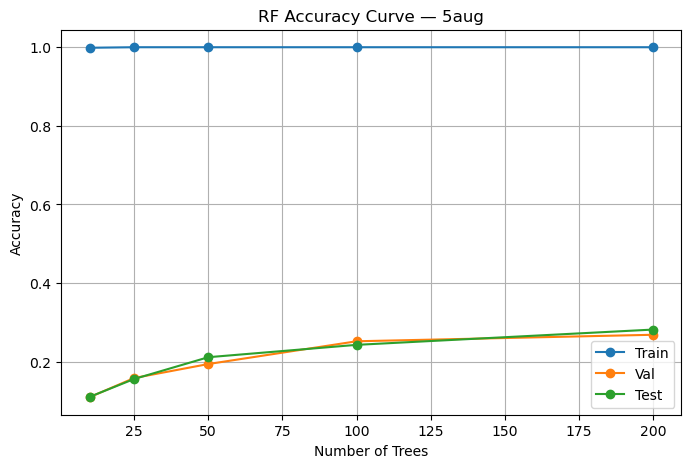

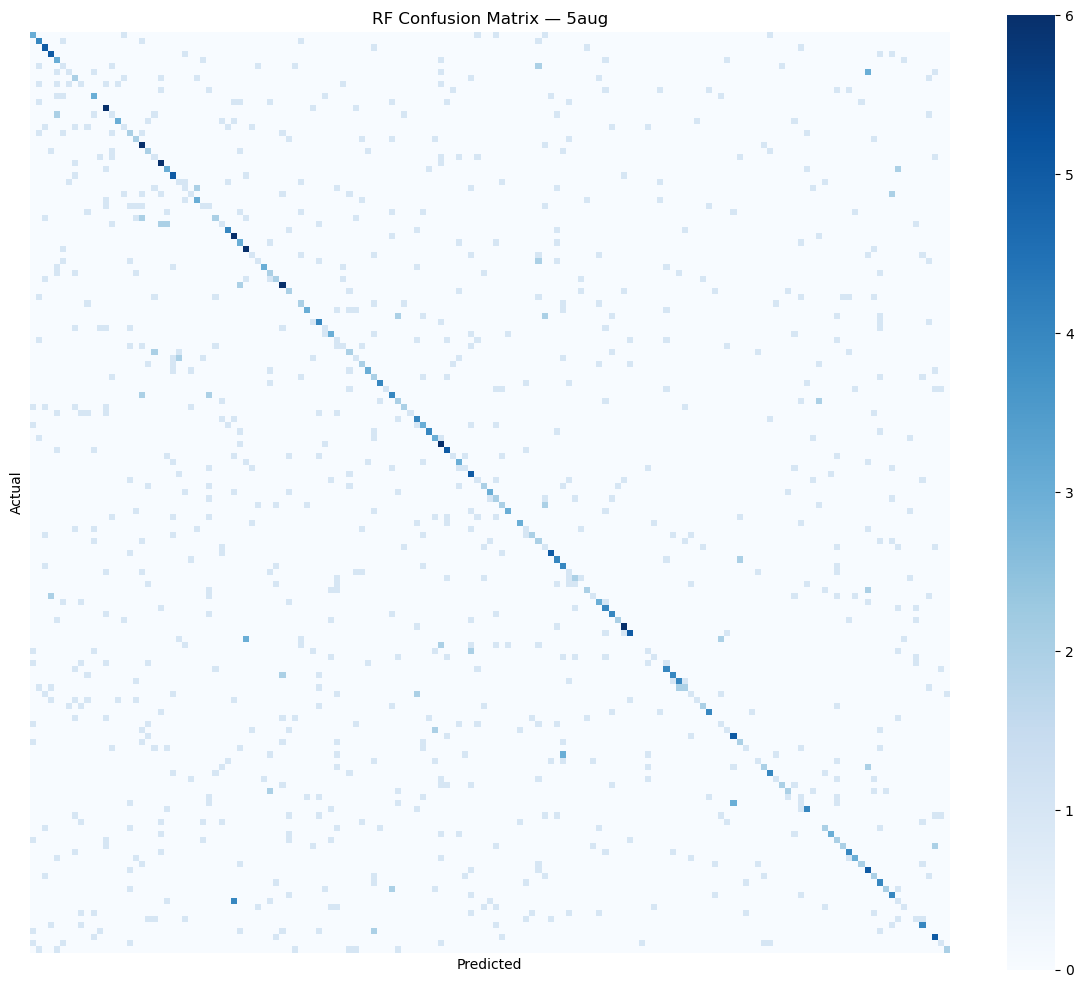


Random Forest — 10aug
  Extracting HOG features (parallelized)...
  Val Accuracy:  100.00%
  Test Accuracy: 30.13%
  ROC-AUC:       0.8144
              precision    recall  f1-score   support

        abra       0.17      0.12      0.14         8
  aerodactyl       0.30      0.38      0.33         8
    alakazam       0.33      0.62      0.43         8
       arbok       0.33      0.62      0.43         8
    arcanine       0.33      0.50      0.40         8
    articuno       0.50      0.25      0.33         8
    beedrill       0.25      0.12      0.17         8
  bellsprout       0.25      0.38      0.30         8
   blastoise       0.00      0.00      0.00         8
   bulbasaur       0.00      0.00      0.00         8
  butterfree       0.50      0.62      0.56         8
    caterpie       0.00      0.00      0.00         8
     chansey       0.20      0.62      0.30         8
   charizard       0.00      0.00      0.00         8
  charmander       0.50      0.12      0.20      

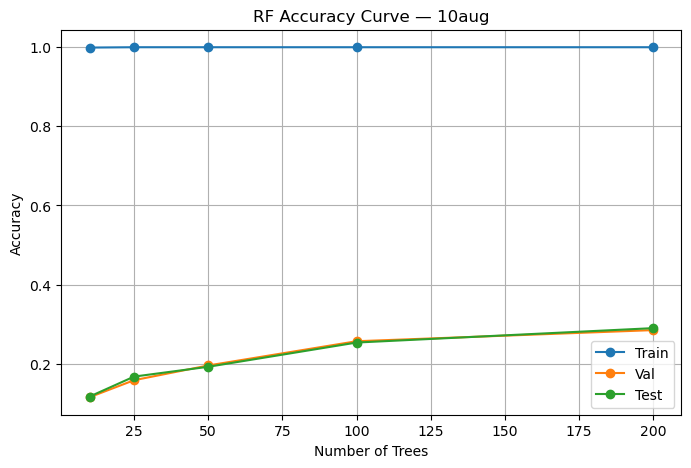

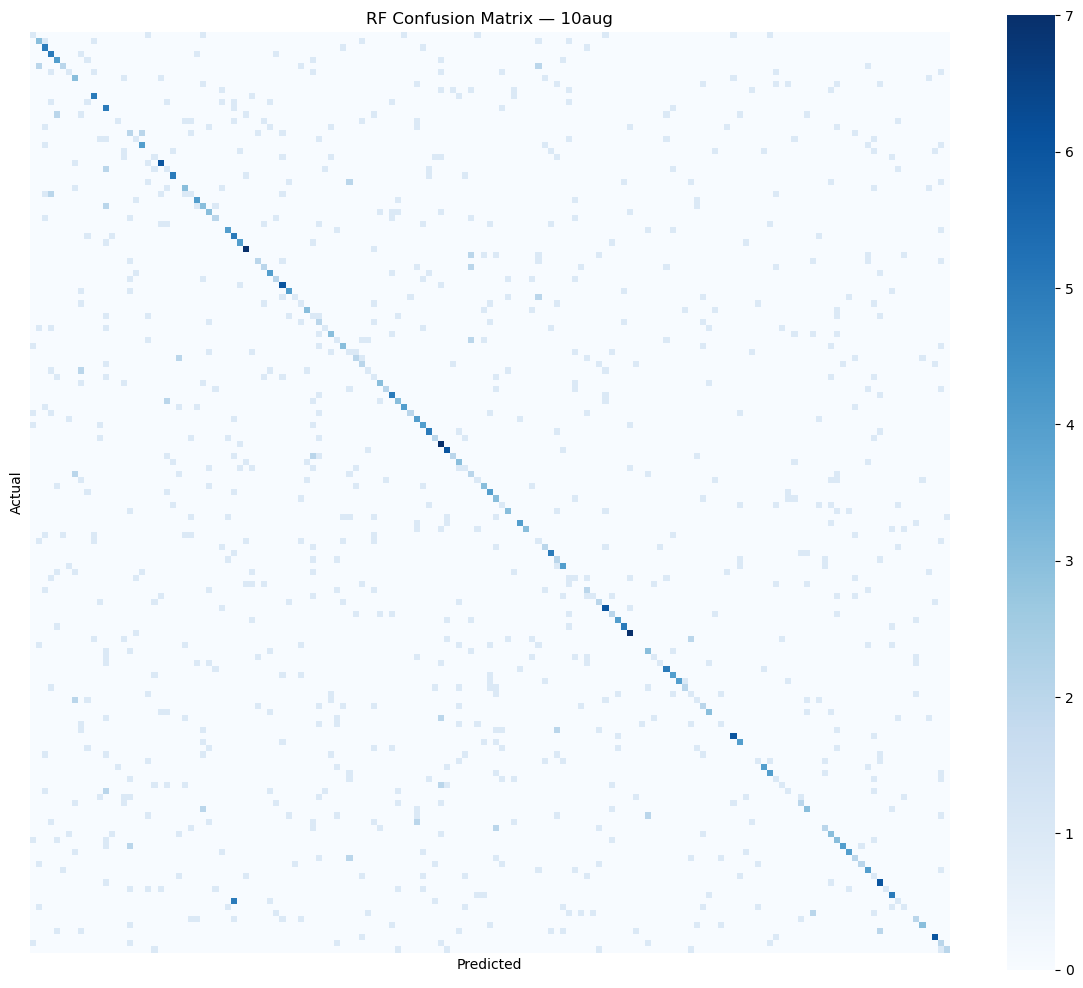


RF results saved to rf_metrics.csv


In [5]:
def extract_hog_features(image_flat):
    image_gray = rgb2gray(image_flat.reshape(64, 64, 3))
    return hog(image_gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False)

def transform_hog(X_train, X_val, X_test):
    print("  Extracting HOG features (parallelized)...")
    X_tr = np.array(Parallel(n_jobs=-1)(delayed(extract_hog_features)(img) for img in X_train))
    X_v  = np.array(Parallel(n_jobs=-1)(delayed(extract_hog_features)(img) for img in X_val))
    X_te = np.array(Parallel(n_jobs=-1)(delayed(extract_hog_features)(img) for img in X_test))
    return X_tr, X_v, X_te

def run_rf_experiment(aug_version):
    print(f"\n{'='*50}\nRandom Forest — {aug_version}\n{'='*50}")
    X_train, X_val, X_test, y_train, y_val, y_test = load_dataset(aug_version)
    X_tr_hog, X_v_hog, X_te_hog = transform_hog(X_train, X_val, X_test)

    # Combine train+val for final fit since we tuned on val
    X_trainval_hog = np.vstack([X_tr_hog, X_v_hog])
    y_trainval     = np.concatenate([y_train, y_val])

    rf = RandomForestClassifier(
        n_estimators=200,       # was 100 — more trees = more stable
        max_features="sqrt",    # standard best practice for classification
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_trainval_hog, y_trainval)

    y_val_pred  = rf.predict(X_v_hog)
    y_test_pred = rf.predict(X_te_hog)
    y_test_prob = rf.predict_proba(X_te_hog)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    roc_auc  = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")

    print(f"  Val Accuracy:  {val_acc:.2%}")
    print(f"  Test Accuracy: {test_acc:.2%}")
    print(f"  ROC-AUC:       {roc_auc:.4f}")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Accuracy curve
    curve = []
    for n in [10, 25, 50, 100, 200]:
        m = RandomForestClassifier(
            n_estimators=n, max_features="sqrt",
            random_state=RANDOM_STATE, n_jobs=-1
        ).fit(X_tr_hog, y_train)
        curve.append({"n_estimators": n,
                      "Train": accuracy_score(y_train, m.predict(X_tr_hog)),
                      "Val":   accuracy_score(y_val,   m.predict(X_v_hog)),
                      "Test":  accuracy_score(y_test,  m.predict(X_te_hog))})
    curve_df = pd.DataFrame(curve)
    plt.figure(figsize=(8, 5))
    for col in ["Train", "Val", "Test"]:
        plt.plot(curve_df["n_estimators"], curve_df[col], marker="o", label=col)
    plt.title(f"RF Accuracy Curve — {aug_version}")
    plt.xlabel("Number of Trees"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True); plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="Blues", cbar=True,
                xticklabels=False, yticklabels=False, square=True)
    plt.title(f"RF Confusion Matrix — {aug_version}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {
        "Model": "Random Forest", "Dataset": aug_version,
        "Validation Accuracy": val_acc, "Accuracy": test_acc,
        "Macro Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Macro Recall":    recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Macro F1":        f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Weighted F1":     f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "ROC-AUC": roc_auc,
    }

rf_5aug  = run_rf_experiment("5aug")   # RUNTIME: ~3 min
rf_10aug = run_rf_experiment("10aug")  # RUNTIME: ~6 min
rf_results_df = pd.DataFrame([rf_5aug, rf_10aug])
rf_results_df.to_csv(Path(DATA_PATH) / "rf_metrics.csv", index=False)
print("\nRF results saved to rf_metrics.csv")


## Section 5: Neural Network


Neural Network — 5aug


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 151)            │        19,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,479,255 (24.72 MB)

 Trainable params: 6,477,463 (24.71 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.0755 - loss: 4.4119 - val_accuracy: 0.1813 - val_loss: 3.6627 - learning_rate: 0.0010
Epoch 2/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.1805 - loss: 3.5777 - val_accuracy: 0.2351 - val_loss: 3.2541 - learning_rate: 0.0010
Epoch 3/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2341 - loss: 3.2303 - val_accuracy: 0.2790 - val_loss: 3.0829 - learning_rate: 0.0010
Epoch 4/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2695 - loss: 3.0309 - val_accuracy: 0.2881 - val_loss: 3.0151 - learning_rate: 0.0010
Epoch 5/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3017 - loss: 2.8600 - val_accuracy: 0.2848 - val_loss: 2.9913 - learning_rate: 0.0010
Epoch 6/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3182 - loss: 2.7296 - val_accuracy: 0.3038 - val_loss: 2.9842 - learning_rate: 0.0010
Epoch 7/50
680/680 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3452 - l

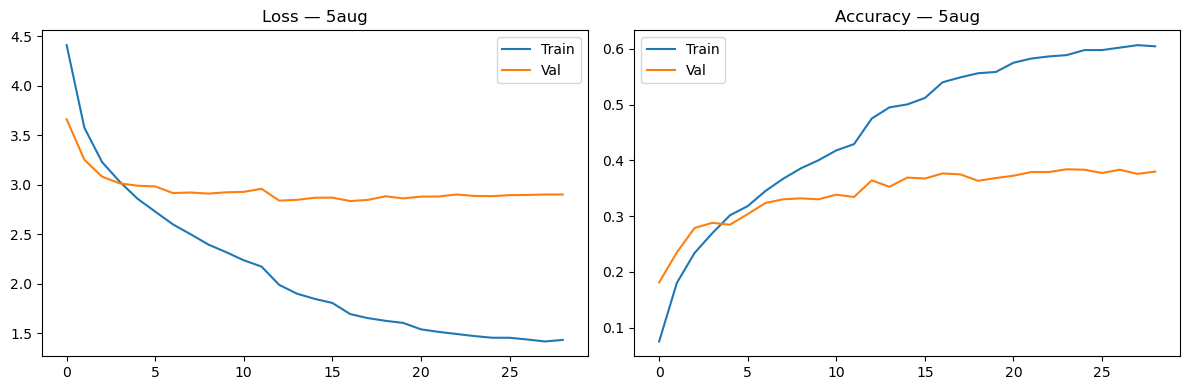

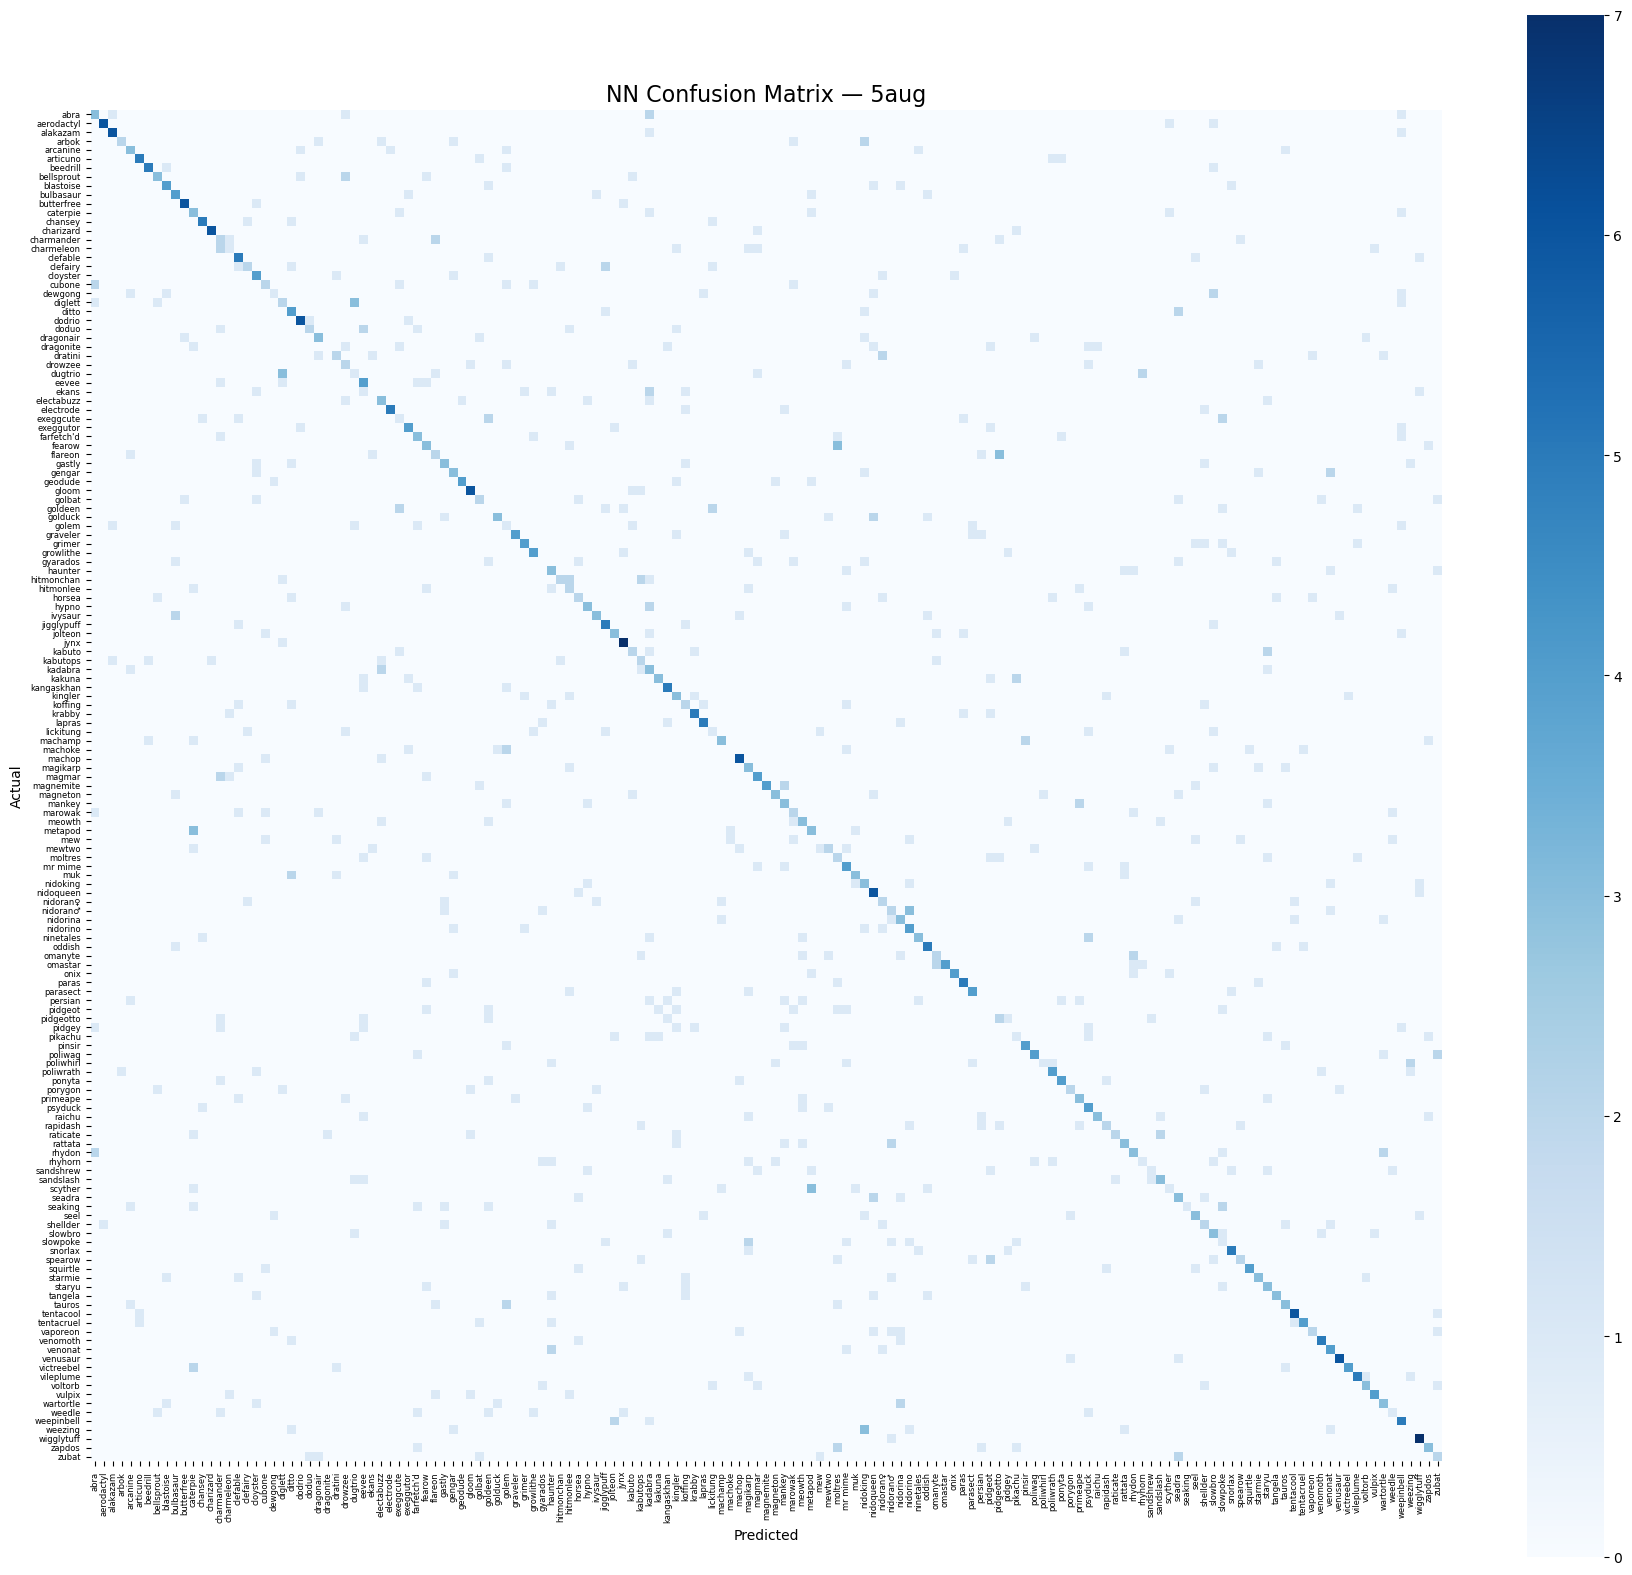


Neural Network — 10aug


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 151)            │        19,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,479,255 (24.72 MB)

 Trainable params: 6,477,463 (24.71 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.0815 - loss: 4.3162 - val_accuracy: 0.1945 - val_loss: 3.4493 - learning_rate: 0.0010
Epoch 2/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.1590 - loss: 3.6880 - val_accuracy: 0.2525 - val_loss: 3.1506 - learning_rate: 0.0010
Epoch 3/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.1983 - loss: 3.4480 - val_accuracy: 0.2806 - val_loss: 2.9612 - learning_rate: 0.0010
Epoch 4/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.2256 - loss: 3.2963 - val_accuracy: 0.3046 - val_loss: 2.9147 - learning_rate: 0.0010
Epoch 5/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.2489 - loss: 3.1620 - val_accuracy: 0.3129 - val_loss: 2.8571 - learning_rate: 0.0010
Epoch 6/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.2670 - loss: 3.0563 - val_accuracy: 0.3055 - val_loss: 2.8701 - learning_rate: 0.0010
Epoch 7/50
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accura

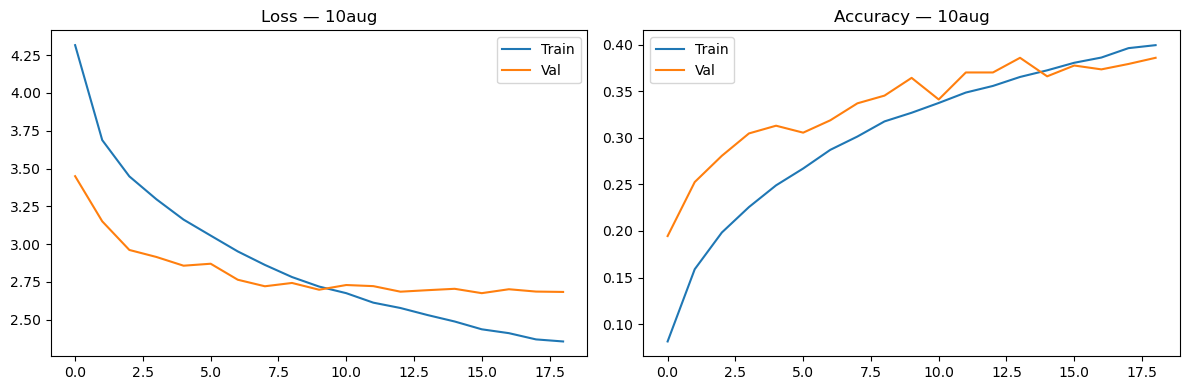

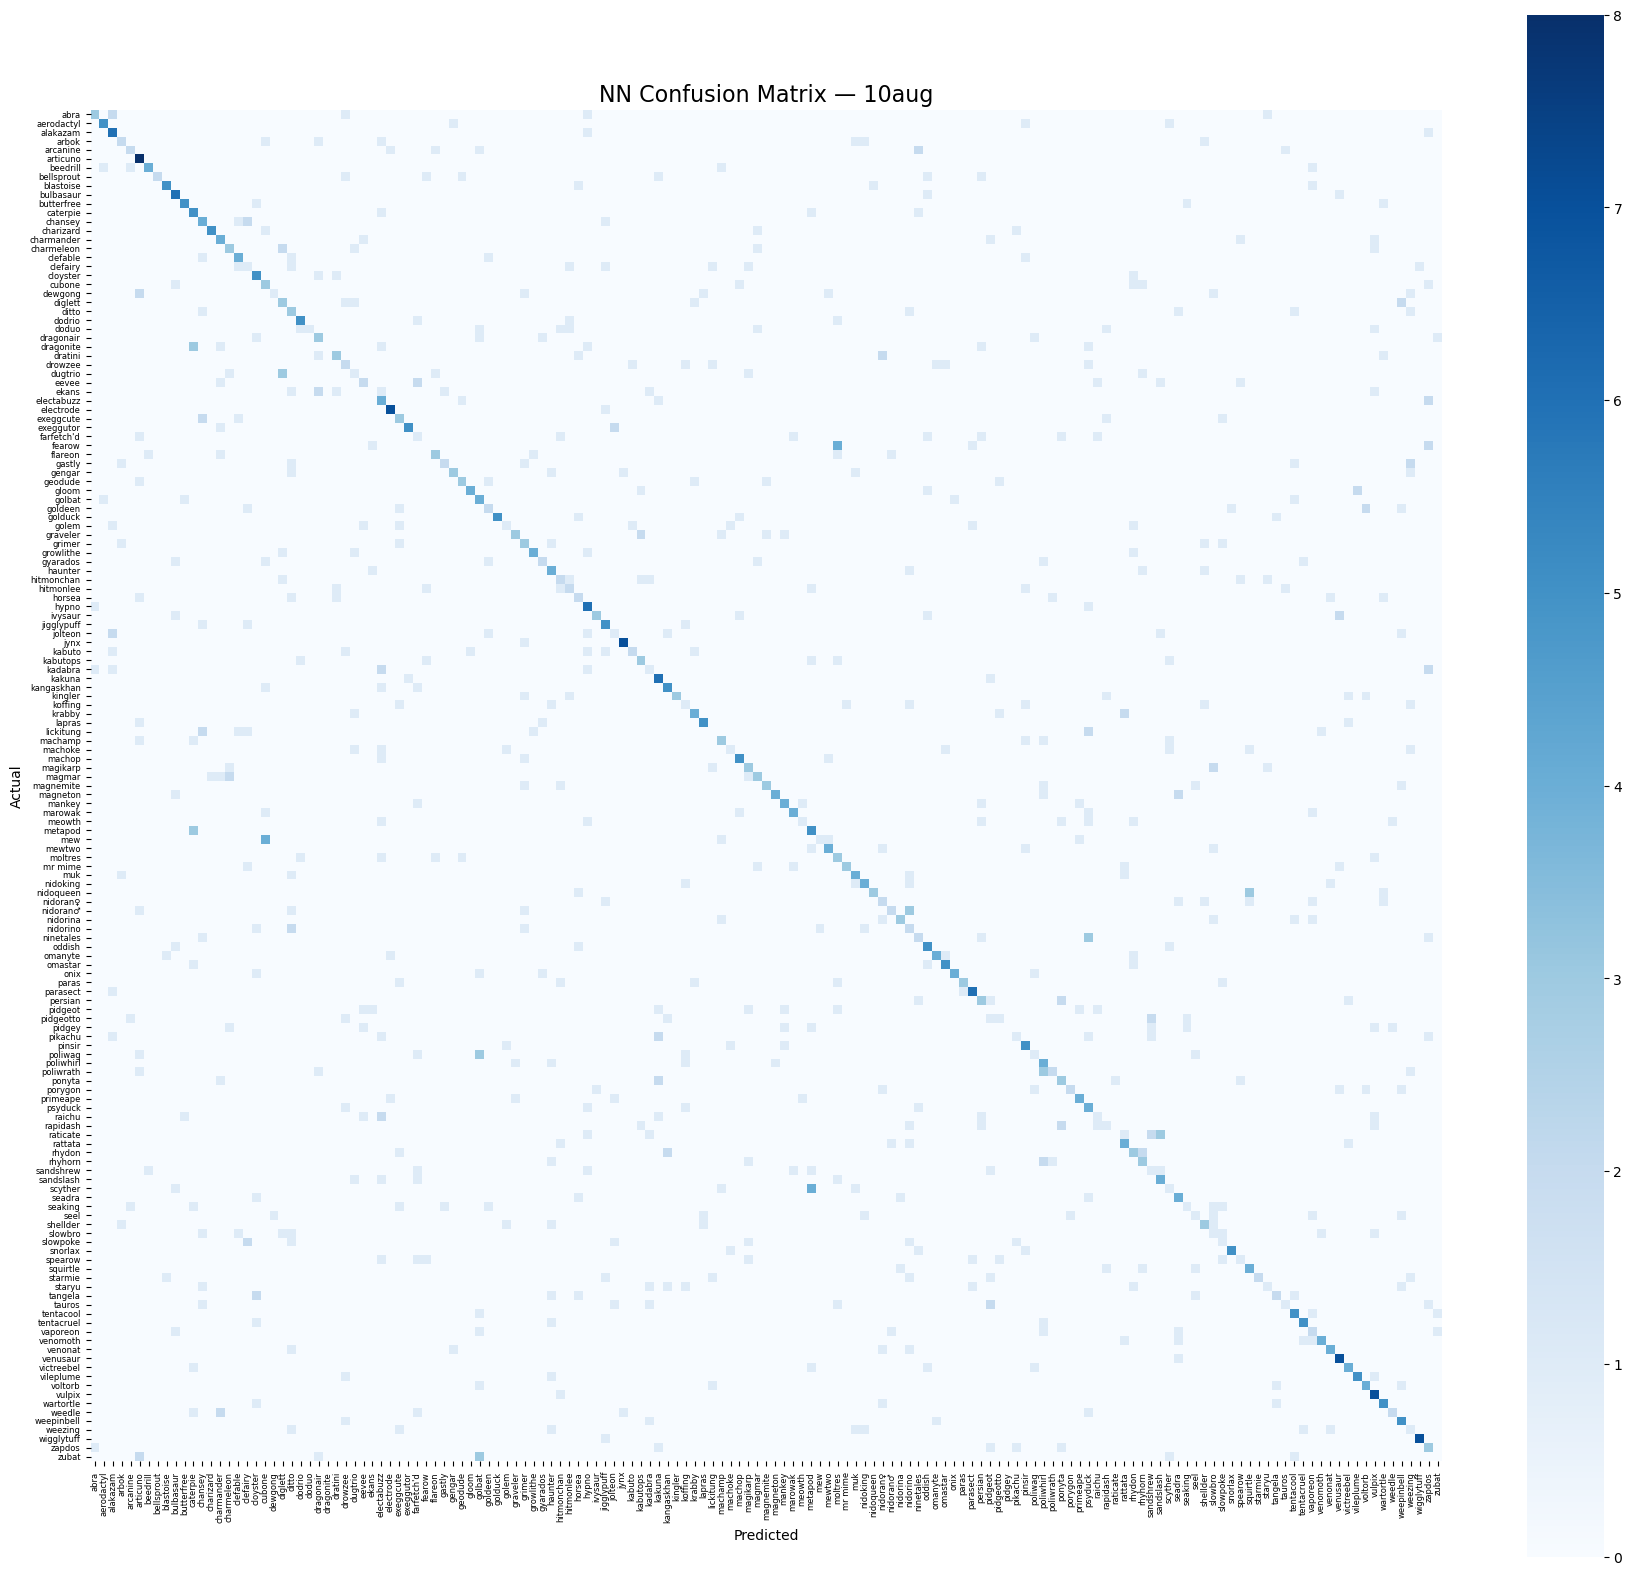


NN results saved to nn_metrics.csv


In [6]:
def preprocess_nn(X_train, X_val, X_test):
    """Normalize only if not already in [0,1], then flatten."""
    if X_train.max() > 1.0:
        X_train, X_val, X_test = X_train/255., X_val/255., X_test/255.
    return (X_train.reshape(len(X_train), -1).astype("float32"),
            X_val.reshape(len(X_val), -1).astype("float32"),
            X_test.reshape(len(X_test), -1).astype("float32"))

def build_nn(input_dim, num_classes):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def run_nn_experiment(aug_version):
    print(f"\n{'='*50}\nNeural Network — {aug_version}\n{'='*50}")
    X_train, X_val, X_test, y_train, y_val, y_test = load_dataset(aug_version)
    X_tr, X_v, X_te = preprocess_nn(X_train, X_val, X_test)

    le = LabelEncoder()
    y_tr  = le.fit_transform(y_train)
    y_v   = le.transform(y_val)
    y_te  = le.transform(y_test)
    class_names = le.classes_

    model = keras.Sequential([
        keras.Input(shape=(X_tr.shape[1],)),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(len(class_names), activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, verbose=1
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        epochs=50,
        batch_size=32,
        validation_data=(X_v, y_v),
        callbacks=callbacks,
        verbose=1,
    )

    loss, acc = model.evaluate(X_te, y_te, verbose=0)
    y_pred_probs = model.predict(X_te, verbose=0)
    y_pred  = np.argmax(y_pred_probs, axis=1)
    roc_auc = roc_auc_score(y_te, y_pred_probs, multi_class="ovr", average="macro")
    report  = classification_report(y_te, y_pred, output_dict=True, zero_division=0)

    print(f"\nTest Accuracy: {acc:.2%} | ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=class_names, zero_division=0))

    # Loss & accuracy plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Val")
    axes[0].set_title(f"Loss — {aug_version}"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"Accuracy — {aug_version}"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, cmap="Blues", cbar=True, square=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.xticks(rotation=90, fontsize=6); plt.yticks(rotation=0, fontsize=6)
    plt.title(f"NN Confusion Matrix — {aug_version}", fontsize=16)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {
        "Model": "Neural Network", "Dataset": aug_version,
        "Validation Accuracy": max(history.history["val_accuracy"]),
        "Accuracy": acc,
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall":    report["macro avg"]["recall"],
        "Macro F1":        report["macro avg"]["f1-score"],
        "Weighted F1":     report["weighted avg"]["f1-score"],
        "ROC-AUC": roc_auc,
    }

nn_5aug  = run_nn_experiment("5aug")   # RUNTIME: ~10 min
nn_10aug = run_nn_experiment("10aug")  # RUNTIME: ~10 min
nn_results_df = pd.DataFrame([nn_5aug, nn_10aug])
nn_results_df.to_csv(Path(DATA_PATH) / "nn_metrics.csv", index=False)
print("\nNN results saved to nn_metrics.csv")

## Section 6: CNN


CNN — 5aug
  Epoch   1/50 | Train 1.75% / 5.0976 | Val 8.77% / 4.6599
  Epoch  10/50 | Train 38.86% / 3.0802 | Val 48.84% / 2.7884
  Epoch  20/50 | Train 59.91% / 2.3219 | Val 58.44% / 2.3582
  Epoch  30/50 | Train 71.68% / 1.9624 | Val 62.75% / 2.2495
  Epoch  40/50 | Train 76.84% / 1.8079 | Val 64.16% / 2.2042
  Epoch  50/50 | Train 78.08% / 1.7737 | Val 64.32% / 2.1911

  Best Val Accuracy: 64.98%


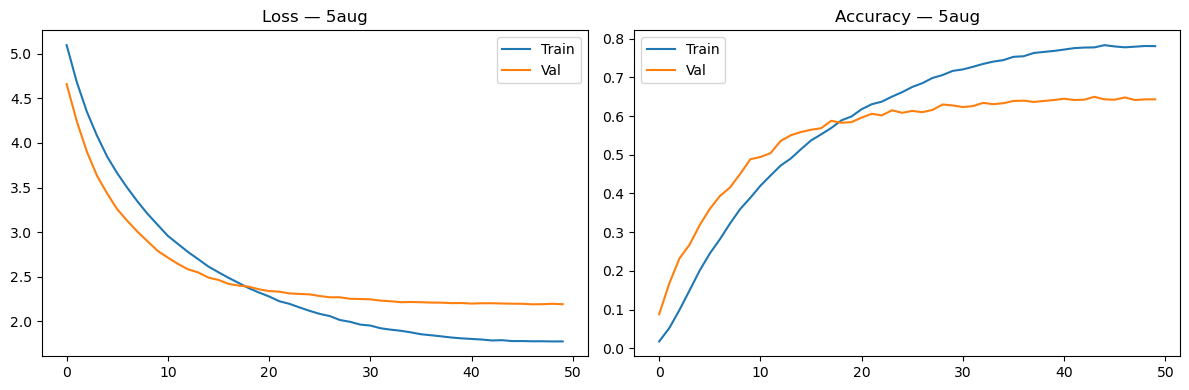


Test Accuracy: 65.23% | ROC-AUC: 0.9860
              precision    recall  f1-score   support

        abra       0.50      0.62      0.56         8
  aerodactyl       0.58      0.88      0.70         8
    alakazam       0.60      0.75      0.67         8
       arbok       0.67      0.75      0.71         8
    arcanine       0.60      0.75      0.67         8
    articuno       0.78      0.88      0.82         8
    beedrill       0.86      0.75      0.80         8
  bellsprout       0.80      0.50      0.62         8
   blastoise       0.62      0.62      0.62         8
   bulbasaur       0.46      0.75      0.57         8
  butterfree       0.71      0.62      0.67         8
    caterpie       0.67      0.50      0.57         8
     chansey       1.00      0.75      0.86         8
   charizard       0.73      1.00      0.84         8
  charmander       0.43      0.75      0.55         8
  charmeleon       0.67      0.50      0.57         8
    clefable       0.67      0.75      0

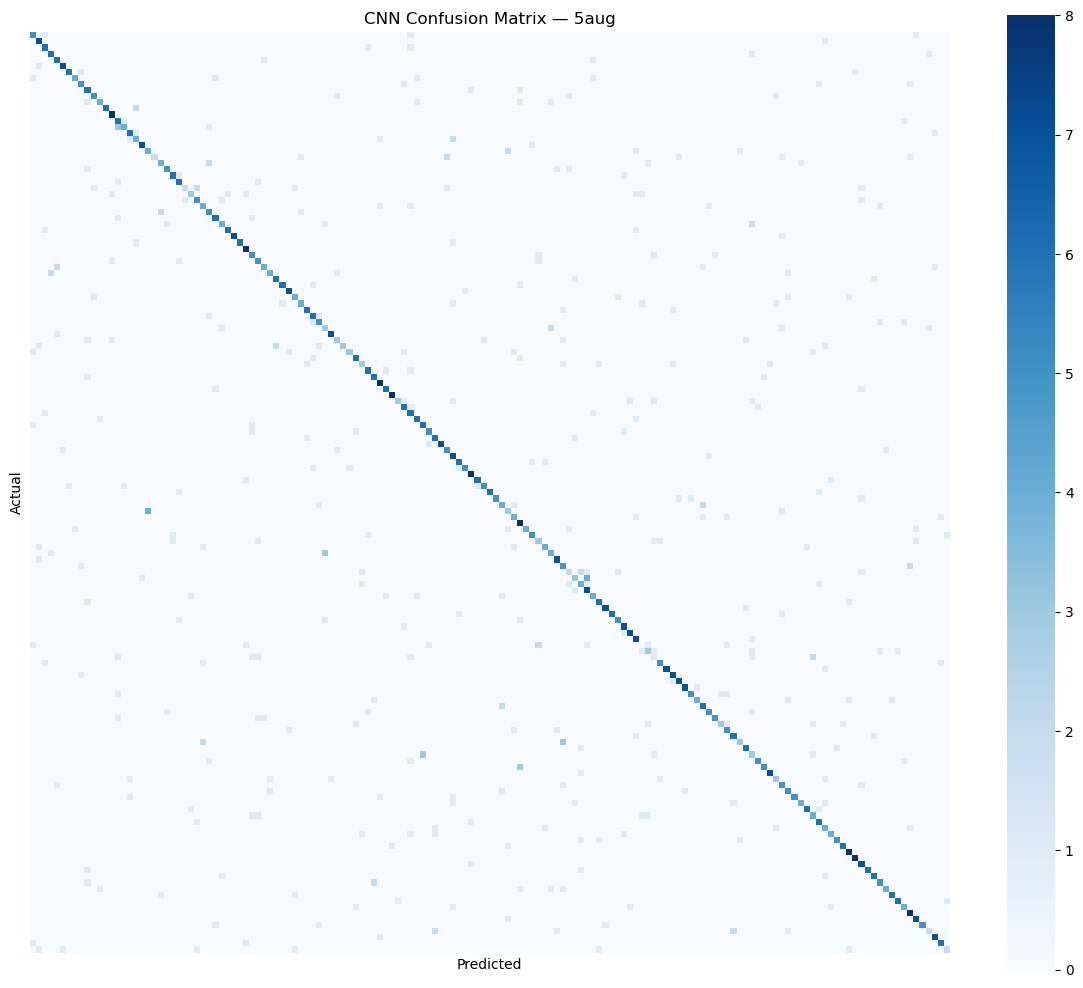


CNN — 10aug
  Epoch   1/50 | Train 2.43% / 4.9886 | Val 10.26% / 4.3634
  Epoch  10/50 | Train 40.75% / 3.0048 | Val 51.90% / 2.6262
  Epoch  20/50 | Train 58.30% / 2.3933 | Val 61.75% / 2.2489
  Epoch  30/50 | Train 66.84% / 2.1151 | Val 65.48% / 2.1441
  Epoch  40/50 | Train 71.44% / 1.9709 | Val 66.64% / 2.1074
  Epoch  50/50 | Train 72.57% / 1.9347 | Val 66.72% / 2.1075

  Best Val Accuracy: 66.80%


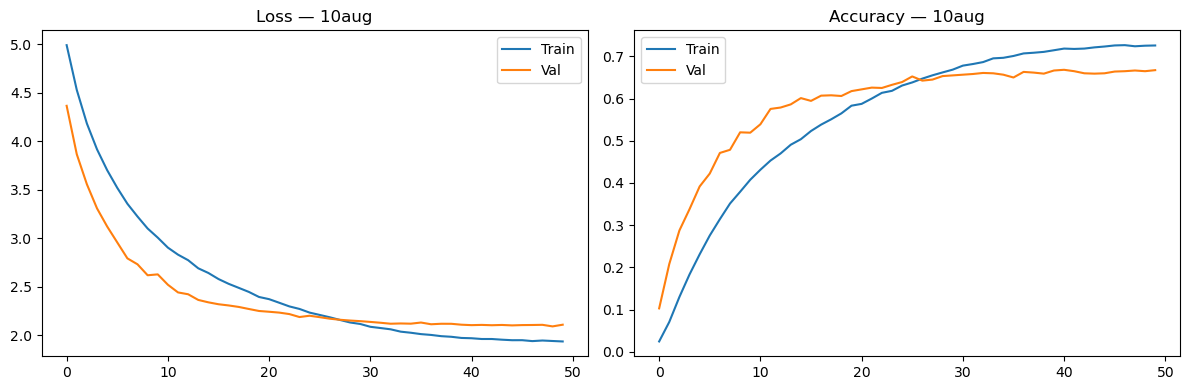


Test Accuracy: 67.22% | ROC-AUC: 0.9867
              precision    recall  f1-score   support

        abra       0.50      0.62      0.56         8
  aerodactyl       1.00      1.00      1.00         8
    alakazam       0.60      0.75      0.67         8
       arbok       0.62      0.62      0.62         8
    arcanine       0.80      0.50      0.62         8
    articuno       0.67      1.00      0.80         8
    beedrill       0.83      0.62      0.71         8
  bellsprout       0.80      0.50      0.62         8
   blastoise       0.75      0.75      0.75         8
   bulbasaur       0.70      0.88      0.78         8
  butterfree       0.75      0.75      0.75         8
    caterpie       0.57      0.50      0.53         8
     chansey       1.00      0.75      0.86         8
   charizard       0.89      1.00      0.94         8
  charmander       0.67      0.75      0.71         8
  charmeleon       1.00      0.62      0.77         8
    clefable       0.75      0.75      0

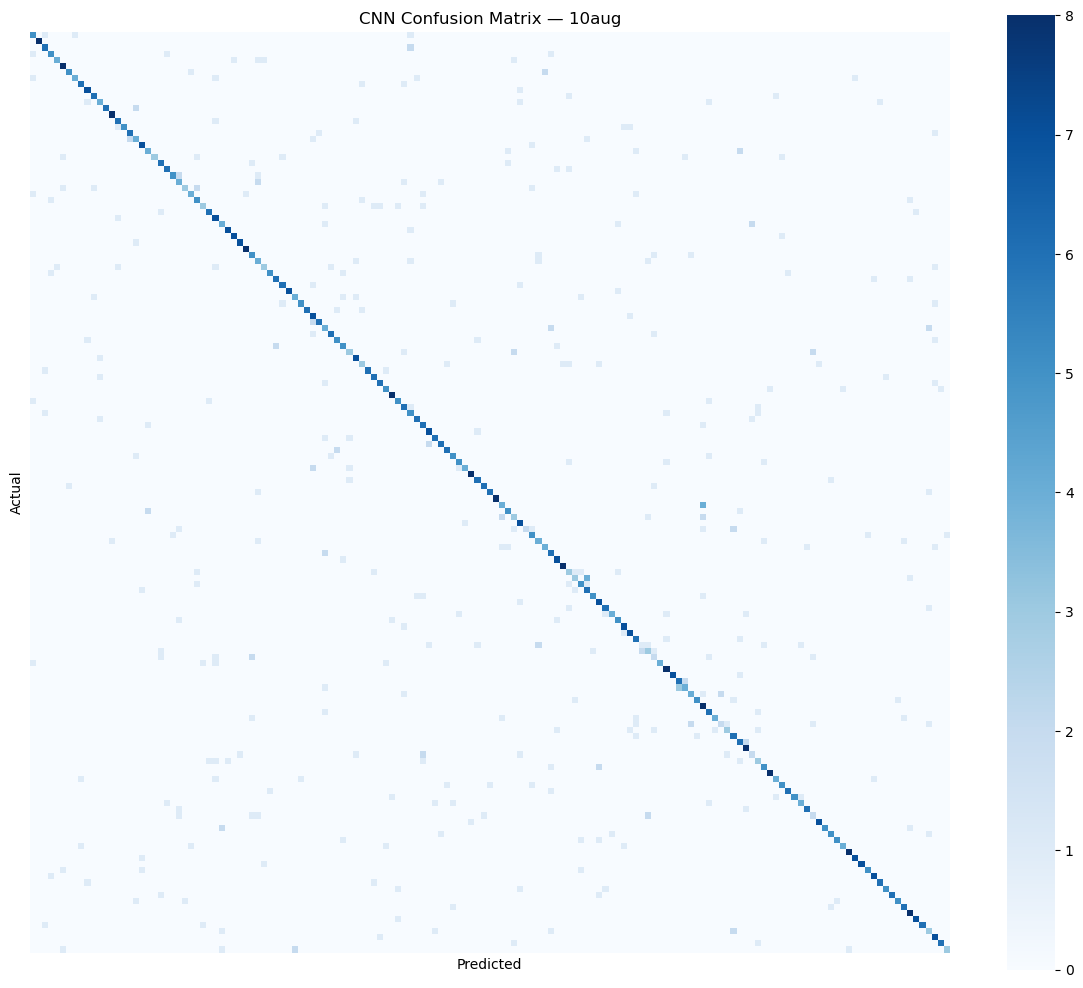


CNN results saved to cnn_metrics.csv


In [7]:
# ── CNN Architecture ──────────────────────────────────────
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(),
            nn.BatchNorm1d(512), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(),
            nn.BatchNorm1d(256), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

# ── Albumentations Transforms ─────────────────────────────
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# ── NumpyDataset ──────────────────────────────────────────
class NumpyDataset(Dataset):
    """Wraps flat .npy arrays into a PyTorch Dataset with optional Albumentations transforms."""
    def __init__(self, X, y, transform=None):
        self.X = (X.reshape(-1, 64, 64, 3) * 255).astype(np.uint8)
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        img = self.X[i]
        if self.transform:
            img = self.transform(image=img)["image"]
        else:
            img = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)
        return img, self.y[i]

# ── run_cnn_experiment ────────────────────────────────────
def run_cnn_experiment(aug_version, epochs=50, batch_size=32, lr=1e-4):
    print(f"\n{'='*50}\nCNN — {aug_version}\n{'='*50}")
    X_train, X_val, X_test, y_train, y_val, y_test = load_dataset(aug_version)

    le = LabelEncoder()
    y_tr  = le.fit_transform(y_train)
    y_v   = le.transform(y_val)
    y_te  = le.transform(y_test)
    class_names = le.classes_

    train_loader = DataLoader(
        NumpyDataset(X_train, y_tr, transform=train_transform),
        batch_size=batch_size, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        NumpyDataset(X_val, y_v, transform=val_transform),
        batch_size=batch_size, shuffle=False, num_workers=0
    )
    test_loader = DataLoader(
        NumpyDataset(X_test, y_te, transform=val_transform),
        batch_size=batch_size, shuffle=False, num_workers=0
    )

    model     = CNN(len(class_names)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_b); loss = criterion(out, y_b)
            loss.backward(); optimizer.step()
            tr_loss    += loss.item() * len(y_b)
            tr_correct += (out.argmax(1) == y_b).sum().item()
            tr_total   += len(y_b)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out  = model(X_b); loss = criterion(out, y_b)
                v_loss    += loss.item() * len(y_b)
                v_correct += (out.argmax(1) == y_b).sum().item()
                v_total   += len(y_b)

        t_acc = tr_correct/tr_total; v_acc = v_correct/v_total
        t_loss = tr_loss/tr_total;   v_loss_avg = v_loss/v_total
        for k, v in zip(["train_loss","train_acc","val_loss","val_acc"],
                        [t_loss, t_acc, v_loss_avg, v_acc]):
            history[k].append(v)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | Train {t_acc:.2%} / {t_loss:.4f} | Val {v_acc:.2%} / {v_loss_avg:.4f}")

    model.load_state_dict(best_state)
    print(f"\n  Best Val Accuracy: {best_val_acc:.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_title(f"Loss — {aug_version}"); axes[0].legend()
    axes[1].plot(history["train_acc"],  label="Train")
    axes[1].plot(history["val_acc"],    label="Val")
    axes[1].set_title(f"Accuracy — {aug_version}"); axes[1].legend()
    plt.tight_layout(); plt.show()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            out   = model(X_b.to(DEVICE))
            probs = F.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y_b.numpy())

    all_probs = np.array(all_probs)
    test_acc  = accuracy_score(all_labels, all_preds)
    roc_auc   = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    report    = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    print(f"\nTest Accuracy: {test_acc:.2%} | ROC-AUC: {roc_auc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="Blues", cbar=True,
                xticklabels=False, yticklabels=False, square=True)
    plt.title(f"CNN Confusion Matrix — {aug_version}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {
        "Model": "CNN", "Dataset": aug_version,
        "Validation Accuracy": best_val_acc,
        "Accuracy": test_acc,
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall":    report["macro avg"]["recall"],
        "Macro F1":        report["macro avg"]["f1-score"],
        "Weighted F1":     report["weighted avg"]["f1-score"],
        "ROC-AUC": roc_auc,
    }

cnn_5aug  = run_cnn_experiment("5aug")   # RUNTIME: ~77 min
cnn_10aug = run_cnn_experiment("10aug")  # RUNTIME: ~117 min
cnn_results_df = pd.DataFrame([cnn_5aug, cnn_10aug])
cnn_results_df.to_csv(Path(DATA_PATH) / "cnn_metrics.csv", index=False)
print("\nCNN results saved to cnn_metrics.csv")

# Section 7: Model Comparison


          Model Dataset  Validation Accuracy  Accuracy  Macro F1  ROC-AUC
 Random Forest    5aug             1.000000  0.291391  0.274948 0.804063
 Random Forest   10aug             1.000000  0.301325  0.284701 0.814398
Neural Network    5aug             0.384106  0.380795  0.377178 0.943349
Neural Network   10aug             0.385762  0.387417  0.377395 0.948327
           CNN    5aug             0.649834  0.652318  0.647281 0.986005
           CNN   10aug             0.668046  0.672185  0.668398 0.986689


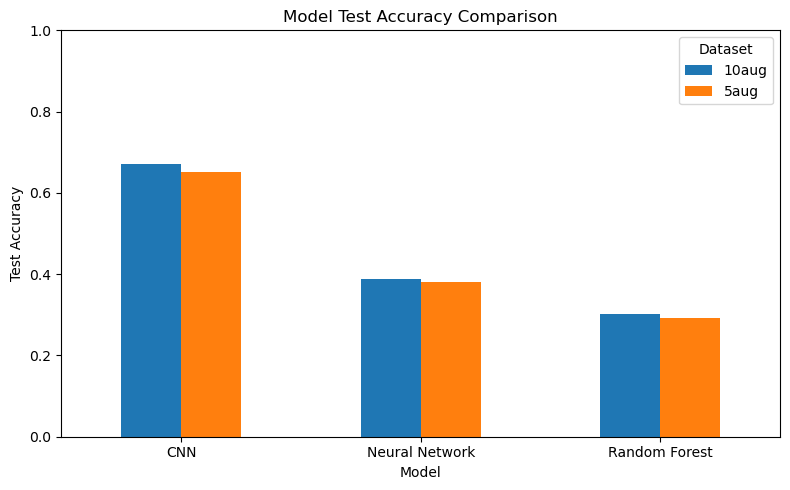

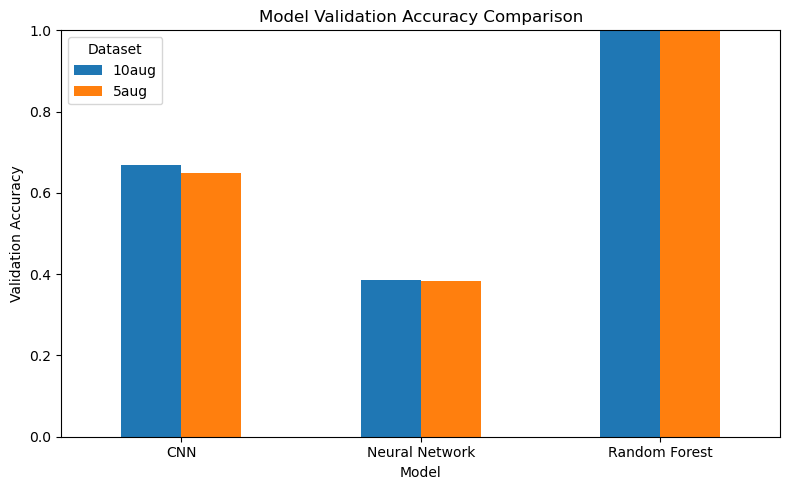

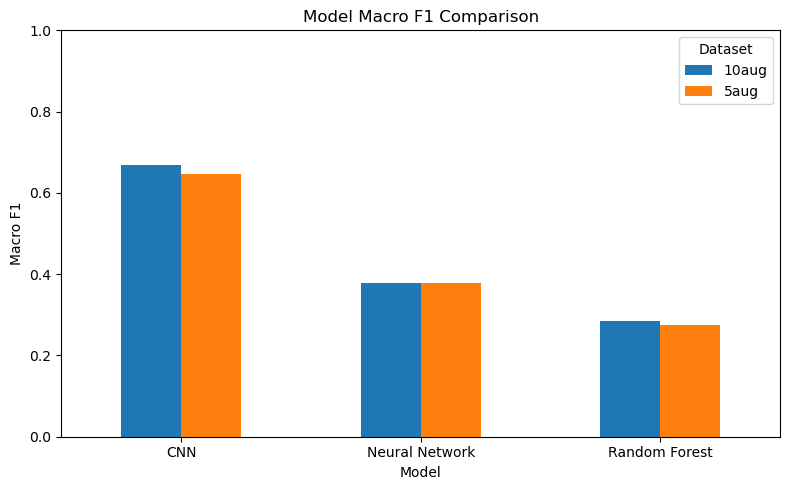

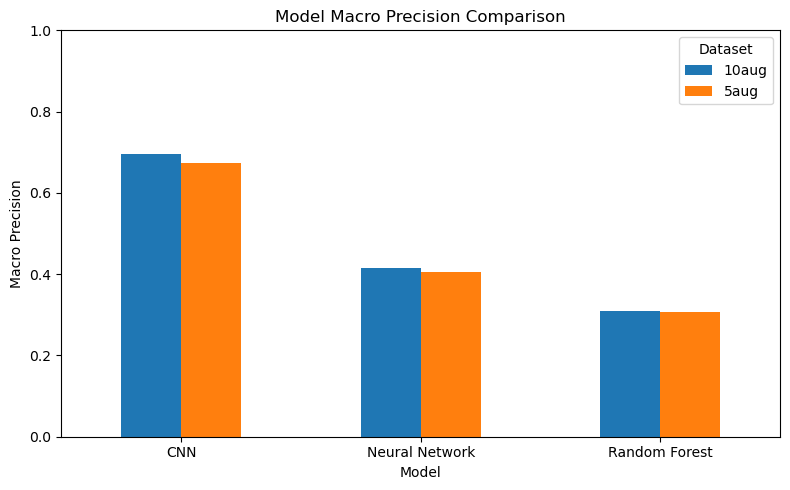

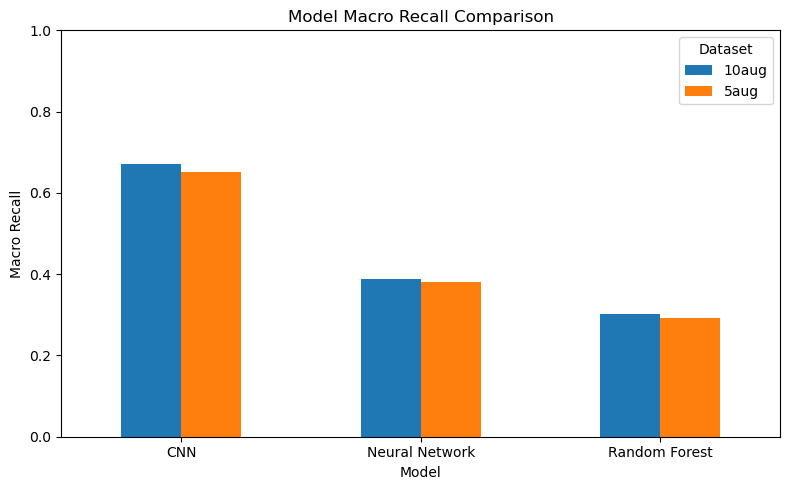

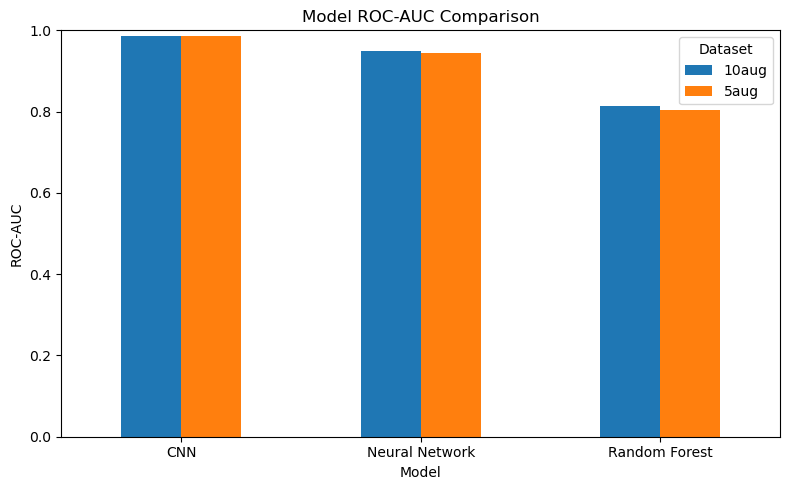

In [8]:
comparison_df = pd.concat([rf_results_df, nn_results_df, cnn_results_df], ignore_index=True)
print("\n", comparison_df[["Model","Dataset","Validation Accuracy","Accuracy","Macro F1","ROC-AUC"]].to_string(index=False))

for metric, title in [
    ("Accuracy",            "Test Accuracy"),
    ("Validation Accuracy", "Validation Accuracy"),
    ("Macro F1",            "Macro F1"),
    ("Macro Precision",     "Macro Precision"),
    ("Macro Recall",        "Macro Recall"),
    ("ROC-AUC",             "ROC-AUC"),
]:
    pivot = comparison_df.pivot(index="Model", columns="Dataset", values=metric)
    pivot.plot(kind="bar", figsize=(8, 5))
    plt.title(f"Model {title} Comparison")
    plt.ylabel(title); plt.xlabel("Model")
    plt.ylim(0, 1); plt.xticks(rotation=0)
    plt.legend(title="Dataset"); plt.tight_layout(); plt.show()